In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import joblib

In [2]:
#loading the dataset
filename= "ObesityDataSet_raw_and_data_sinthetic.csv"
df = pd.read_csv(filename)
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [3]:
#to check datatypes and null values
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [4]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


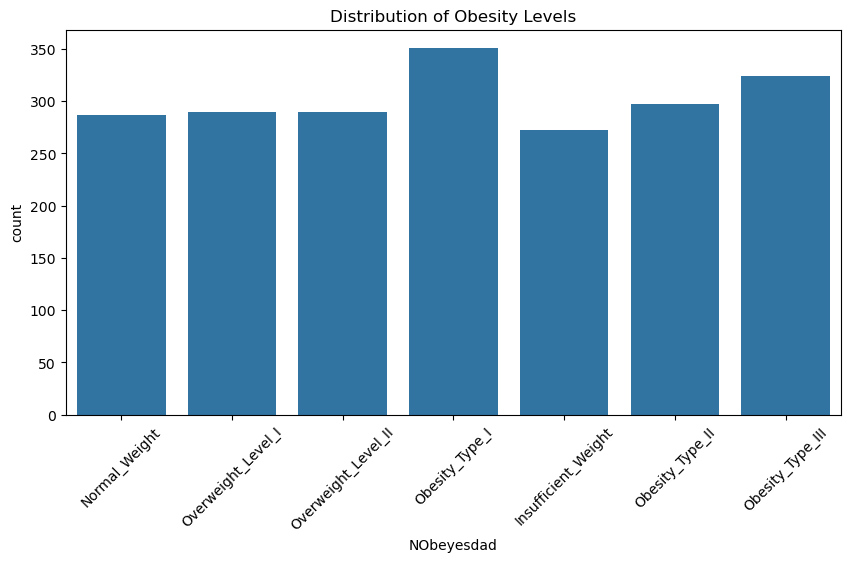

In [5]:
#To check if classes are balanced 

plt.figure(figsize=(10, 5))
sns.countplot(x='NObeyesdad', data=df)
plt.xticks(rotation = 45)
plt.title("Distribution of Obesity Levels")
plt.show()


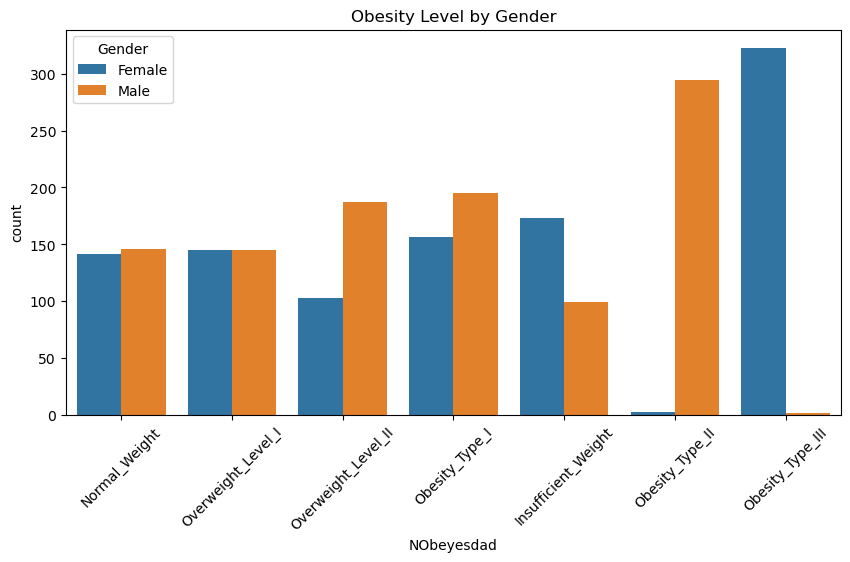

In [6]:
# to check if classes are balanced with respect to gender
plt.figure(figsize=(10, 5))
sns.countplot(x='NObeyesdad', hue='Gender', data=df)
plt.xticks(rotation=45)
plt.title("Obesity Level by Gender")
plt.show()

In [7]:
#checking unique values in for FCVC
print(df['FCVC'].describe())
print(df['FCVC'].value_counts().sort_index().head(20))


count    2111.000000
mean        2.419043
std         0.533927
min         1.000000
25%         2.000000
50%         2.385502
75%         3.000000
max         3.000000
Name: FCVC, dtype: float64
FCVC
1.000000    33
1.003566     1
1.005578     1
1.008760     1
1.031149     1
1.036159     1
1.036414     1
1.052699     1
1.053534     1
1.063449     1
1.064162     1
1.067909     1
1.078529     1
1.081585     1
1.081600     1
1.096455     1
1.108663     1
1.116068     1
1.118436     1
1.122127     1
Name: count, dtype: int64


In [8]:
#checking unique values
print(df['FCVC'].value_counts().sort_index())
print(df['NCP'].value_counts().sort_index())
print(df['CH2O'].value_counts().sort_index())
print(df['FAF'].value_counts().sort_index())
print(df['TUE'].value_counts().sort_index())

FCVC
1.000000     33
1.003566      1
1.005578      1
1.008760      1
1.031149      1
           ... 
2.996717      1
2.997524      1
2.997951      1
2.998441      1
3.000000    652
Name: count, Length: 810, dtype: int64
NCP
1.000000    199
1.000283      1
1.000414      1
1.000610      1
1.001383      1
           ... 
3.995957      1
3.998618      1
3.998766      1
3.999591      1
4.000000     69
Name: count, Length: 635, dtype: int64
CH2O
1.000000    211
1.000463      1
1.000536      1
1.000544      1
1.000695      1
           ... 
2.991671      1
2.993448      1
2.994515      1
2.999495      1
3.000000    162
Name: count, Length: 1268, dtype: int64
FAF
0.000000    411
0.000096      1
0.000272      1
0.000454      1
0.001015      1
           ... 
2.939733      1
2.971832      1
2.998981      1
2.999918      1
3.000000     75
Name: count, Length: 1190, dtype: int64
TUE
0.000000    557
0.000073      1
0.000355      1
0.000436      1
0.001096      1
           ... 
1.980875      1
1.98

In [9]:
print(df.nunique()) #uniqe values for all features

Gender                               2
Age                               1402
Height                            1574
Weight                            1525
family_history_with_overweight       2
FAVC                                 2
FCVC                               810
NCP                                635
CAEC                                 4
SMOKE                                2
CH2O                              1268
SCC                                  2
FAF                               1190
TUE                               1129
CALC                                 4
MTRANS                               5
NObeyesdad                           7
dtype: int64


In [10]:
#most of the columns which should have values like 1,2,3, have values like 1.0023,2.0045, so rounding them to the whole numbers
df['FCVC'] = df['FCVC'].round().astype(int)
df['NCP'] = df['NCP'].round().astype(int)
df['CH2O'] = df['CH2O'].round().astype(int)
df['FAF'] = df['FAF'].round().astype(int)
df['TUE'] = df['TUE'].round().astype(int)

In [11]:
#mapping the correct categories for features

fcvc_map = {1: 'Never', 2: 'Sometimes', 3: 'Always'}
df['FCVC'] = df['FCVC'].map(fcvc_map)

ncp_map = {1: 'Btwn 1 & 2', 2: "3", 3: 'More than 3', 4: "No Answer"}
df['NCP'] = df['NCP'].map(ncp_map)

ch2o_map = {1: 'less than 1L', 2: 'Btwn 1L & 2L', 3: 'More than 2L'}
df['CH2O'] = df['CH2O'].map(ch2o_map)

faf_map = {0: 'Never', 1: '1 to 2times', 2: '2 to 4 times', 3:"4 or 5 times"}
df['FAF'] = df['FAF'].map(faf_map)

tue_map = {0: '0 to 2h', 1: '3 to 5h', 2: 'More than 5h'}
df['TUE'] = df['TUE'].map(tue_map)



In [12]:
df.head() #now we have all the categorical features as true categorical and ready to encode

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,Sometimes,More than 3,Sometimes,no,Btwn 1L & 2L,no,Never,3 to 5h,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,Always,More than 3,Sometimes,yes,More than 2L,yes,4 or 5 times,0 to 2h,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,Sometimes,More than 3,Sometimes,no,Btwn 1L & 2L,no,2 to 4 times,3 to 5h,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,Always,More than 3,Sometimes,no,Btwn 1L & 2L,no,2 to 4 times,0 to 2h,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,Sometimes,Btwn 1 & 2,Sometimes,no,Btwn 1L & 2L,no,Never,0 to 2h,Sometimes,Public_Transportation,Overweight_Level_II


In [13]:
# to check the name of the categories for encoding
for col in df.columns:
    print(col)
    print(df[col].unique())

Gender
['Female' 'Male']
Age
[21.       23.       27.       ... 22.524036 24.361936 23.664709]
Height
[1.62     1.52     1.8      ... 1.752206 1.73945  1.738836]
Weight
[ 64.        56.        77.       ... 133.689352 133.346641 133.472641]
family_history_with_overweight
['yes' 'no']
FAVC
['no' 'yes']
FCVC
['Sometimes' 'Always' 'Never']
NCP
['More than 3' 'Btwn 1 & 2' 'No Answer' '3']
CAEC
['Sometimes' 'Frequently' 'Always' 'no']
SMOKE
['no' 'yes']
CH2O
['Btwn 1L & 2L' 'More than 2L' 'less than 1L']
SCC
['no' 'yes']
FAF
['Never' '4 or 5 times' '2 to 4 times' '1 to 2times']
TUE
['3 to 5h' '0 to 2h' 'More than 5h']
CALC
['no' 'Sometimes' 'Frequently' 'Always']
MTRANS
['Public_Transportation' 'Walking' 'Automobile' 'Motorbike' 'Bike']
NObeyesdad
['Normal_Weight' 'Overweight_Level_I' 'Overweight_Level_II'
 'Obesity_Type_I' 'Insufficient_Weight' 'Obesity_Type_II'
 'Obesity_Type_III']


In [14]:
from sklearn.preprocessing import OrdinalEncoder

#encoding categorical columns
ordinal_cols = [ 'FCVC', 'NCP', 'CAEC', 'CH2O', 'FAF', 'TUE', 'CALC', 'family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC', 'Gender']
onehot_cols = ['MTRANS']
label_cols = ["NObeyesdad"]

ordinal_categories = {
    'FCVC': ["Never", "Sometimes", "Always"],
    'NCP': ["Btwn 1 & 2","3", "More than 3", "No Answer"],  
    'CAEC': ['no', 'Sometimes', 'Frequently', "Always"],  
    'CH2O': ['less than 1L', 'Btwn 1L & 2L', 'More than 2L' ],  
    'FAF': ['Never','1 to 2times','2 to 4 times', '4 or 5 times'],  
    'TUE': ['0 to 2h','3 to 5h', 'More than 5h'],  
    'CALC': ['no', 'Sometimes', 'Frequently', 'Always'], 
    'family_history_with_overweight': ['no', 'yes'],  
    'FAVC': ['no', 'yes'],  
    'SMOKE': ['no', 'yes'],  
    'SCC': ['no', 'yes'],  
    'Gender': ['Female', 'Male']  
}
# Initialize the OrdinalEncoder
ordinal_encoders = {}
for col, categories in ordinal_categories.items():
    df[col] = df[col].astype(str)
    categories = [str(cat) for cat in categories]
    ord_enc = OrdinalEncoder(categories=[categories])
    df[[col]] = ord_enc.fit_transform(df[[col]])
    ordinal_encoders[col] = ord_enc

In [15]:
# Save encoders for reuse
joblib.dump(ordinal_encoders, 'encoders/ordinal_encoders.pkl')

['encoders/ordinal_encoders.pkl']

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   float64
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   float64
 5   FAVC                            2111 non-null   float64
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   float64
 9   SMOKE                           2111 non-null   float64
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   float64
 12  FAF                             21

In [17]:
# onehot encoding
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse=False, handle_unknown='ignore')
encoded = ohe.fit_transform(df[onehot_cols])

encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(onehot_cols))

# Concatenate with original DataFrame 
df = df.drop(columns=onehot_cols)
df = pd.concat([df, encoded_df], axis=1)


In [18]:
joblib.dump(ohe, 'encoders/onehot_encoder_MTRANS.pkl')

['encoders/onehot_encoder_MTRANS.pkl']

In [19]:
from sklearn.preprocessing import LabelEncoder

# Label encoding the target column
le_target = LabelEncoder()
df['NObeyesdad'] = le_target.fit_transform(df['NObeyesdad'])



In [20]:
joblib.dump(le_target, 'encoders/label_encoder_target.pkl')

['encoders/label_encoder_target.pkl']

In [21]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,...,SCC,FAF,TUE,CALC,NObeyesdad,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,0.0,21.0,1.62,64.0,1.0,0.0,1.0,2.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1,0.0,0.0,0.0,1.0,0.0
1,0.0,21.0,1.52,56.0,1.0,0.0,2.0,2.0,1.0,1.0,...,1.0,3.0,0.0,1.0,1,0.0,0.0,0.0,1.0,0.0
2,1.0,23.0,1.80,77.0,1.0,0.0,1.0,2.0,1.0,0.0,...,0.0,2.0,1.0,2.0,1,0.0,0.0,0.0,1.0,0.0
3,1.0,27.0,1.80,87.0,0.0,0.0,2.0,2.0,1.0,0.0,...,0.0,2.0,0.0,2.0,5,0.0,0.0,0.0,0.0,1.0
4,1.0,22.0,1.78,89.8,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,6,0.0,0.0,0.0,1.0,0.0


In [22]:
from sklearn.preprocessing import StandardScaler
import joblib

# features to be scaled
scale_cols = ['Age', 'Height', 'Weight']

#scaling
scaler = StandardScaler()

# Fit and transform the features
df[scale_cols] = scaler.fit_transform(df[scale_cols])


In [23]:
# Save the scaler for future use 
joblib.dump(scaler, 'scalers/scaler.pkl')

['scalers/scaler.pkl']

In [24]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,...,SCC,FAF,TUE,CALC,NObeyesdad,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,0.0,-0.522124,-0.875589,-0.862558,1.0,0.0,1.0,2.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1,0.0,0.0,0.0,1.0,0.0
1,0.0,-0.522124,-1.947599,-1.168077,1.0,0.0,2.0,2.0,1.0,1.0,...,1.0,3.0,0.0,1.0,1,0.0,0.0,0.0,1.0,0.0
2,1.0,-0.206889,1.054029,-0.366090,1.0,0.0,1.0,2.0,1.0,0.0,...,0.0,2.0,1.0,2.0,1,0.0,0.0,0.0,1.0,0.0
3,1.0,0.423582,1.054029,0.015808,0.0,0.0,2.0,2.0,1.0,0.0,...,0.0,2.0,0.0,2.0,5,0.0,0.0,0.0,0.0,1.0
4,1.0,-0.364507,0.839627,0.122740,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,6,0.0,0.0,0.0,1.0,0.0


In [25]:
df_scaled_encoded = df.copy() #to keep things easy to understand
df_original = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv") #original df for visualisation use

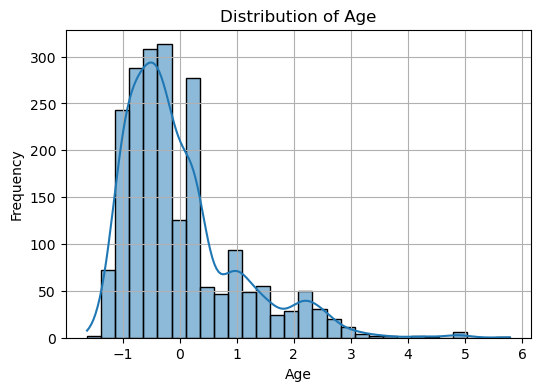

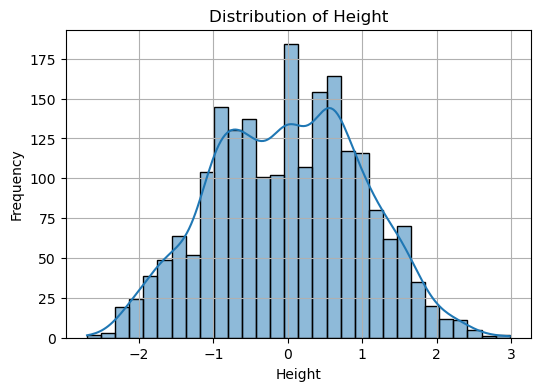

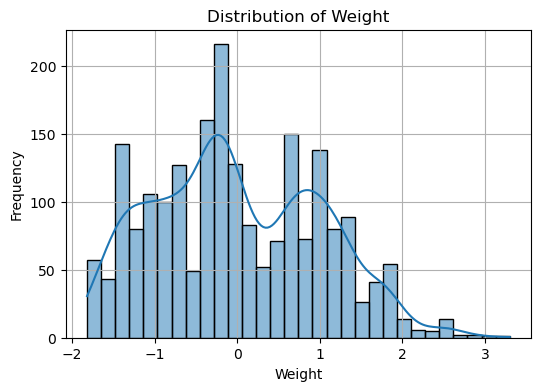

In [26]:
#to check skewness visually 
for col in ['Age', 'Height', 'Weight']:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()


In [27]:
#to check skewness
df_scaled_encoded[['Age', 'Height', 'Weight']].skew()

Age       1.529100
Height   -0.012855
Weight    0.255410
dtype: float64

In [28]:
#using yeo-johnson transformer to handle the skewness in Age
from sklearn.preprocessing import PowerTransformer
skewed_col = ["Age"]
df_transformed = df_scaled_encoded
pt = PowerTransformer(method='yeo-johnson')


df_transformed[skewed_col] = pt.fit_transform(df_transformed[skewed_col])

In [29]:
joblib.dump(pt, 'transformers/yeojohn_ptransformer.pkl')

['transformers/yeojohn_ptransformer.pkl']

In [30]:
#to check skewness again
df_scaled_encoded[['Age', 'Height', 'Weight']].skew()

Age       0.105573
Height   -0.012855
Weight    0.255410
dtype: float64

In [31]:
df_scaled_encoded["Age"].head()

0   -0.428730
1   -0.428730
2    0.070002
3    0.753990
4   -0.165504
Name: Age, dtype: float64

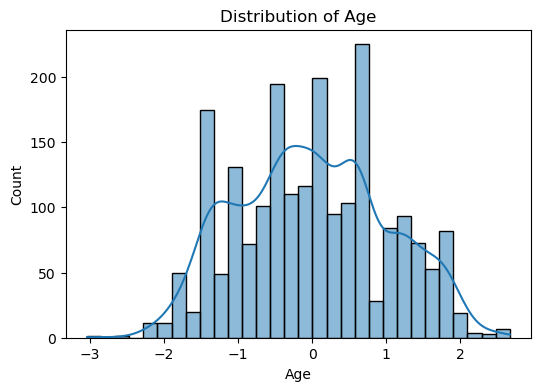

In [32]:
#checking the skewness again for age column
plt.figure(figsize = (6,4))
sns.histplot(df_scaled_encoded["Age"], kde = True, bins = 30)
plt.title("Distribution of Age")
plt.show()

In [33]:
#balancing imbalanced class with respect to gender using SMOTE

'''from imblearn.over_sampling import SMOTE
#creating seperate dataframes for males and females
df_male = df_scaled_encoded[df_scaled_encoded["Gender"]==1]
df_female = df_scaled_encoded[df_scaled_encoded["Gender"]==0]

#seperating features and target column
x_male = df_male.drop(columns = "NObeyesdad")
y_male = df_male["NObeyesdad"]

print("Male Class Distribution:")
print(y_male.value_counts())



#resampling
smote = SMOTE(random_state = 42, k_neighbors = 1)
x_male_resampled, y_male_resampled = smote.fit_resample(x_male, y_male)

#seperating features and target column
x_female = df_female.drop(columns = "NObeyesdad")
y_female = df_female["NObeyesdad"]

print("Female Class Distribution:")
print(y_female.value_counts())
x_female_resampled, y_female_resampled = smote.fit_resample(x_female, y_female)


#converting back to dataframes
df_male_resampled = pd.DataFrame(x_male_resampled, columns = x_male_resampled.columns)
df_male_resampled["NObeyesdad"] = y_male_resampled

df_female_resampled = pd.DataFrame(x_female_resampled, columns = x_female_resampled.columns)
df_female_resampled["NObeyesdad"] = y_female_resampled

#merging both genders
df_resampled = pd.concat([df_male_resampled, df_female_resampled], axis = 0) 
df_resampled = df_resampled.sample(frac = 1, random_state = 42).reset_index(drop = True)'''


'from imblearn.over_sampling import SMOTE\n#creating seperate dataframes for males and females\ndf_male = df_scaled_encoded[df_scaled_encoded["Gender"]==1]\ndf_female = df_scaled_encoded[df_scaled_encoded["Gender"]==0]\n\n#seperating features and target column\nx_male = df_male.drop(columns = "NObeyesdad")\ny_male = df_male["NObeyesdad"]\n\nprint("Male Class Distribution:")\nprint(y_male.value_counts())\n\n\n\n#resampling\nsmote = SMOTE(random_state = 42, k_neighbors = 1)\nx_male_resampled, y_male_resampled = smote.fit_resample(x_male, y_male)\n\n#seperating features and target column\nx_female = df_female.drop(columns = "NObeyesdad")\ny_female = df_female["NObeyesdad"]\n\nprint("Female Class Distribution:")\nprint(y_female.value_counts())\nx_female_resampled, y_female_resampled = smote.fit_resample(x_female, y_female)\n\n\n#converting back to dataframes\ndf_male_resampled = pd.DataFrame(x_male_resampled, columns = x_male_resampled.columns)\ndf_male_resampled["NObeyesdad"] = y_male_res

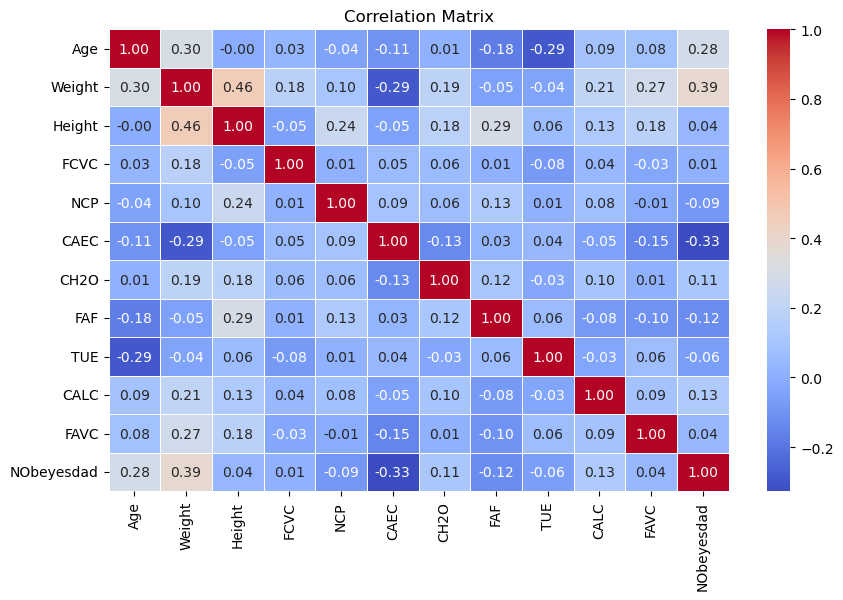

In [34]:
corr_matrix = df_transformed[['Age', 'Weight', 'Height', 'FCVC', 'NCP', 'CAEC', 'CH2O', 'FAF', 'TUE', 'CALC', 'FAVC', "NObeyesdad"]].corr()
# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

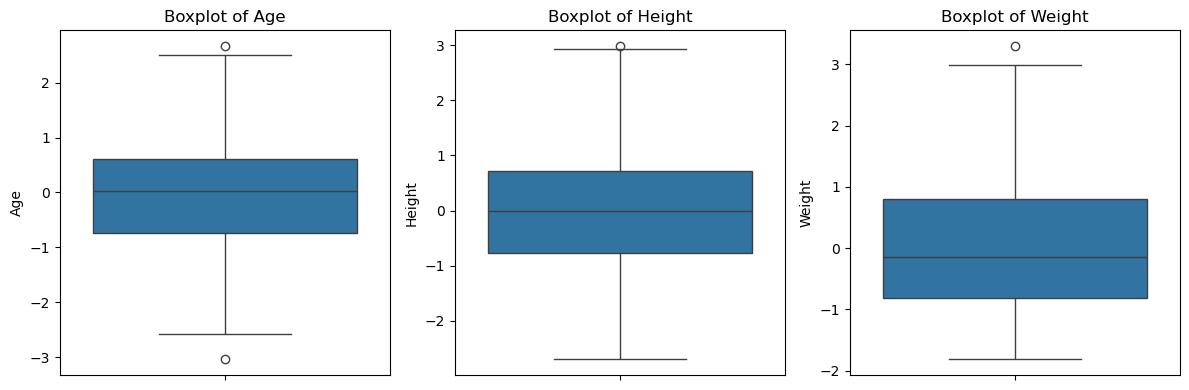

In [35]:
#box plots to check for outliers
numerical_cols = ['Age', 'Height', 'Weight']

plt.figure(figsize=(12, 4))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df_scaled_encoded[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()


In [36]:
#using IQR method to remove ouliers
def remove_outliers_iqr(df_scaled_encoded, column):
    Q1 = df_scaled_encoded[column].quantile(0.25)
    Q3 = df_scaled_encoded[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df_scaled_encoded[(df_scaled_encoded[column] >= lower) & (df_scaled_encoded[column] <= upper)]

for col in numerical_cols:
    df_preprocessed = remove_outliers_iqr(df_scaled_encoded, col)


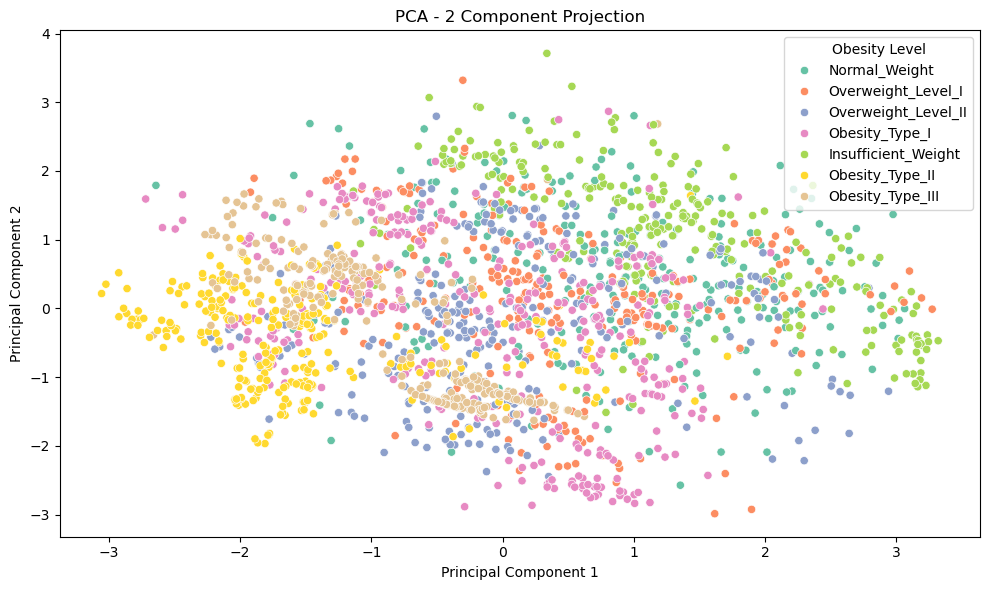

In [37]:
from sklearn.decomposition import PCA

# Dropping the target column
X = df_preprocessed.drop(columns=['NObeyesdad'])
y = df_preprocessed['NObeyesdad']

# reducing to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Convert to DataFrame for plotting
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['NObeyesdad'] = df_original["NObeyesdad"]

# Plotting
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='NObeyesdad', palette='Set2')
plt.title('PCA - 2 Component Projection')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Obesity Level')
plt.tight_layout()
plt.show()


In [38]:
df_preprocessed.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,...,SCC,FAF,TUE,CALC,NObeyesdad,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,0.0,-0.428730,-0.875589,-0.862558,1.0,0.0,1.0,2.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1,0.0,0.0,0.0,1.0,0.0
1,0.0,-0.428730,-1.947599,-1.168077,1.0,0.0,2.0,2.0,1.0,1.0,...,1.0,3.0,0.0,1.0,1,0.0,0.0,0.0,1.0,0.0
2,1.0,0.070002,1.054029,-0.366090,1.0,0.0,1.0,2.0,1.0,0.0,...,0.0,2.0,1.0,2.0,1,0.0,0.0,0.0,1.0,0.0
3,1.0,0.753990,1.054029,0.015808,0.0,0.0,2.0,2.0,1.0,0.0,...,0.0,2.0,0.0,2.0,5,0.0,0.0,0.0,0.0,1.0
4,1.0,-0.165504,0.839627,0.122740,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,6,0.0,0.0,0.0,1.0,0.0


In [39]:
#saving the preprocessed df as a CSV file for further use
df_preprocessed.to_csv("preprocessed_obesity.csv", index = False)